In [ ]:
import os
import sys
import ipywidgets as widgets
from ipywidgets import interact
import torch
import matplotlib.pyplot as plt
import numpy as np

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.dataset import SymbolicDataset, HandDrawnAugmentation  # noqa: E402


In [2]:
dataset = SymbolicDataset("/home/yauheni/pet_project/Plot2Eq/data", drawn_augmentation=True, p=1)

Загружаем 57 файлов в память


100%|██████████| 57/57 [00:05<00:00, 10.25it/s]


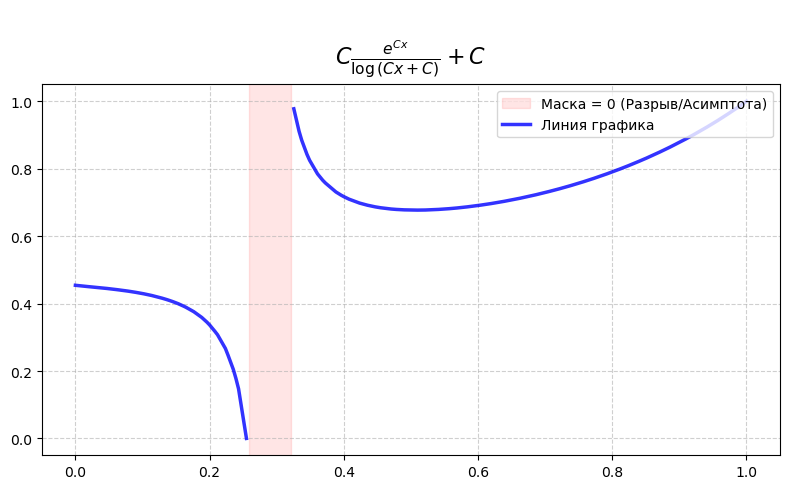

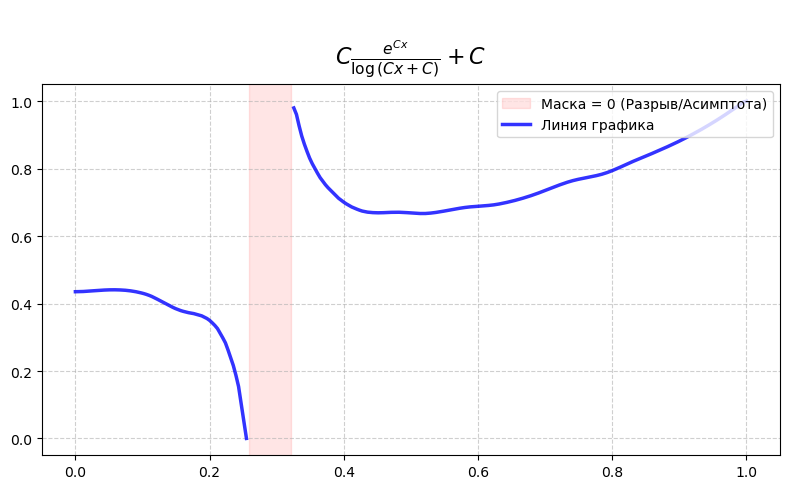

In [12]:
dataset.visualize(104)
dataset.visualize(104, apply_transform=True)

In [3]:
def explore_augmentations(index, max_drift_scale=0.005, max_wobble_scale=0.015):
    points_orig = dataset.points[index].clone()
    tokens = dataset.tokens[index]

    clean_tokens =[t.item() for t in tokens if t.item() not in (0, 1, 2)]
    try:
        expr_str = str(dataset.tokenizer.token_seq_to_expr(torch.tensor(clean_tokens)))
    except Exception as e:
        expr_str = f"Ошибка декодирования: {e}"

    transform = HandDrawnAugmentation(max_drift_scale, max_wobble_scale, p=1.0)
    points_aug = transform(points_orig)

    def plot_on_axis(ax, points, title):
        y_vals = points[0].cpu().numpy()
        mask = points[1].cpu().numpy()
        x_vals = np.linspace(0, 1, len(y_vals))

        y_plot = y_vals.copy()
        y_plot[mask == 0.0] = np.nan

        ax.fill_between(
            x_vals, -0.05, 1.05, where=(mask == 0.0), 
            color="red", alpha=0.1, label="Маска = 0",
            transform=ax.get_xaxis_transform()
        )

        ax.plot(x_vals, y_plot, linewidth=2.5, color="blue", alpha=0.8, label="График")
        
        ax.set_title(title, fontsize=12)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(loc="upper right")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    plot_on_axis(axes[0], points_orig, "Оригинал")
    plot_on_axis(axes[1], points_aug, f"Аугментация (Drift: {max_drift_scale}, Wobble: {max_wobble_scale})")
    
    fig.suptitle(f"Скелет: {expr_str}", fontsize=15, y=1.05)
    plt.tight_layout()
    plt.show()

In [ ]:
interact(
    explore_augmentations,
    index=widgets.IntSlider(min=0, max=len(dataset)-1, step=1, value=0, description='Index:'),
    max_drift_scale=widgets.FloatSlider(
        min=0.00, max=0.150, step=0.001, value=0.005, 
        readout_format='.3f', description='Drift:'
    ),
    max_wobble_scale=widgets.FloatSlider(
        min=0.00, max=0.150, step=0.001, value=0.010, 
        readout_format='.3f', description='Wobble:'
    )
);

interactive(children=(IntSlider(value=0, description='Index:', max=1475501), FloatSlider(value=0.005, descript…